#**Karar Ağacı ile KDDC'99 veri seti üzerinde bir Ağ Saldırı türü sınıflandırma**

**DİLAVER ŞAHİN**

**No:215509031**

**Makina Öğrenmesi methodu olan Karar ağacı **

> KDD Cup 1999 veri kümesi: Veri kümesi, askeri bir bilgisayar ağının simülasyonudur; kayıtlar, normal bağlantılar veya tespit edilen izinsiz giriş (belirli bir saldırı türüyle) olarak sınıflandırılan internet bağlantılarından oluşur.

Veri setini buradan çektim:
http://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html


 # Gerekli kütüphaneleri colabda var olsa da güncellerini indirmesi için çalıştırıyorum.

In [1]:
# Gerekli kütüphaneleri yükleyin
!pip install scikit-learn pandas matplotlib seaborn --quiet

# Gerekli kütüphaneleri yükleyelim

In [2]:
# Gerekli kütüphaneleri yükleyin
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from google.colab import drive

#Drive colaba bağlayarak veri setimizi alıyoruz

In [3]:
# Google drive mount ederek veri setini alma
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ***Sütun Türlerini ve csv foramtındaki data setimizi yüklüyoruz: ***
Veri kümesinin 42 farklı sütun bulunmaktadır ve bu sütunlar aşağıda verilmiştir. Sütunlar, kodlanması gereken kategorik verileri veya normalleştirilmesi gereken sürekli değerleri tanımlayabilir.

data değişkenimzin tanımlı olup olmadığını kontrol ediyoruz.

In [4]:
import pandas as pd
# CSV formatındaki veri setini yükleyin
file_path = '/content/drive/My Drive/kddcup.data.corrected'  # Dosyanızın yolu
columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land",
           "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in", "num_compromised",
           "root_shell", "su_attempted", "num_root", "num_file_creations", "num_shells",
           "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login",
           "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
           "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
           "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
           "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
           "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "attack",
           "last_flag"]

data = pd.read_csv(file_path, header=None, names=columns)
data.head()

pd.set_option('display.max_rows', 10)


In [5]:
if 'data' in globals():
    print("data değişkeni tanımlı.")
else:
    print("data değişkeni tanımlı değil.")

data değişkeni tanımlı.


# **Veriyi keşfetmek ve eksik değerleri kontrol etmek**

Verilerimzin doğru çıkıp çıkmadığını kontrol edip sutun ve rowların düzgünce parse edildiğini kontrol ediyoruz.

In [6]:
# Veri keşfi
print("Veri Seti Boyutları:", data.shape)
print("Eksik Değerler:\n", data.isnull().sum())

# Saldırı türlerine göre dağılım
print("\nSaldırı Türleri Dağılımı:\n", data['attack'].value_counts())

# Özet istatistikler
data.describe()


Veri Seti Boyutları: (4898431, 43)
Eksik Değerler:
 duration                          0
protocol_type                     0
service                           0
flag                              0
src_bytes                         0
                             ...   
dst_host_srv_serror_rate          0
dst_host_rerror_rate              0
dst_host_srv_rerror_rate          0
attack                            0
last_flag                   4898431
Length: 43, dtype: int64

Saldırı Türleri Dağılımı:
 attack
smurf.        2807886
neptune.      1072017
normal.        972781
satan.          15892
ipsweep.        12481
               ...   
ftp_write.          8
multihop.           7
phf.                4
perl.               3
spy.                2
Name: count, Length: 23, dtype: int64


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,last_flag
count,4.898431e+06,4.898431e+06,4.898431e+06,4.898431e+06,4.898431e+06,4.898431e+06,4.898431e+06,4.898431e+06,4.898431e+06,4.898431e+06,...,4.898431e+06,4.898431e+06,4.898431e+06,4.898431e+06,4.898431e+06,4.898431e+06,4.898431e+06,4.898431e+06,4.898431e+06,0.0
mean,4.834243e+01,1.834621e+03,1.093623e+03,5.716116e-06,6.487792e-04,7.961733e-06,1.243766e-02,3.205108e-05,1.435290e-01,8.088304e-03,...,1.892142e+02,7.537132e-01,3.071111e-02,6.050520e-01,6.464107e-03,1.780911e-01,1.778859e-01,5.792780e-02,5.765941e-02,NaN
std,7.233298e+02,9.414311e+05,6.450123e+05,2.390833e-03,4.285434e-02,7.215084e-03,4.689782e-01,7.299408e-03,3.506116e-01,3.856481e+00,...,1.059128e+02,4.111860e-01,1.085432e-01,4.809877e-01,4.125978e-02,3.818382e-01,3.821774e-01,2.309428e-01,2.309777e-01,NaN
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
25%,0.000000e+00,4.500000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.900000e+01,4.100000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
50%,0.000000e+00,5.200000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.550000e+02,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
75%,0.000000e+00,1.032000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.550000e+02,1.000000e+00,4.000000e-02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
max,5.832900e+04,1.379964e+09,1.309937e+09,1.000000e+00,3.000000e+00,1.400000e+01,7.700000e+01,5.000000e+00,1.000000e+00,7.479000e+03,...,2.550000e+02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,NaN


# **Saldırı türlerine göre dağılımı tablolaştırıyoruz.**

Smurf atağının DDOS türü olab bir atak bunun çoğunlukla olduğunu görüyoruz.

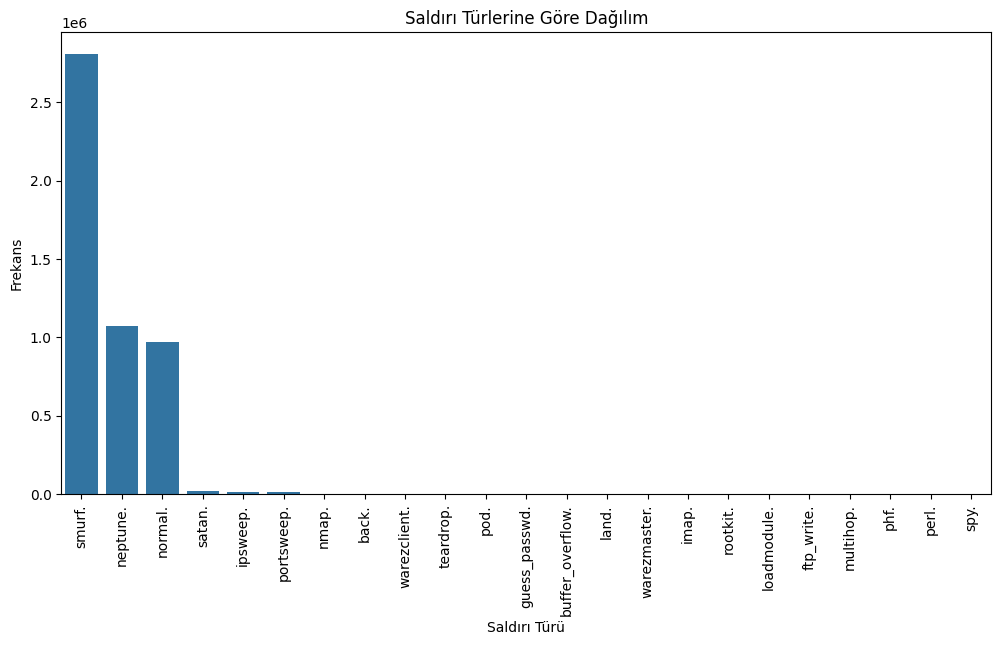

In [7]:
# Saldırı türlerine göre dağılımı görselleştirme
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='attack', order=data['attack'].value_counts().index)
plt.title("Saldırı Türlerine Göre Dağılım")
plt.xlabel("Saldırı Türü")
plt.ylabel("Frekans")
plt.xticks(rotation=90)
plt.show()


# **Veri setiğimizdeki atak türlerini listeliyoruz.**

In [8]:
print(data['attack'].unique())

['normal.' 'buffer_overflow.' 'loadmodule.' 'perl.' 'neptune.' 'smurf.'
 'guess_passwd.' 'pod.' 'teardrop.' 'portsweep.' 'ipsweep.' 'land.'
 'ftp_write.' 'back.' 'imap.' 'satan.' 'phf.' 'nmap.' 'multihop.'
 'warezmaster.' 'warezclient.' 'spy.' 'rootkit.']


# **Sınıflandırmada kullanacağımzı atak türlerini haritasını çıkarıp kontrolünü yapıyoruz.**

In [9]:
# İkili sınıflandırma hedef değişkeni
data['binary_label'] = data['attack'].apply(lambda x: 0 if x == "normal" else 1)

# Çoklu sınıflandırma hedef değişkeni
attack_mapping = {
    "normal.": "normal",  # Normal traffic
    "neptune.": "dos",    # DoS attack
    "smurf.": "dos",      # DoS attack
    "teardrop.": "dos",   # DoS attack
    "land.": "dos",       # DoS attack
    "back.": "dos",       # DoS attack (added based on context)
    "pod.": "dos",        # DoS attack (added based on context)
    "satan.": "probe",    # Probing/scanning attack
    "ipsweep.": "probe",  # Probing/scanning attack
    "portsweep.": "probe",# Probing/scanning attack
    "nmap.": "probe",     # Probing/scanning attack
    "guess_passwd.": "r2l",  # Remote-to-local attack
    "ftp_write.": "r2l",     # Remote-to-local attack
    "imap.": "r2l",          # Remote-to-local attack
    "phf.": "r2l",           # Remote-to-local attack
    "multihop.": "r2l",      # Remote-to-local attack
    "warezmaster.": "r2l",   # Remote-to-local attack
    "warezclient.": "r2l",   # Remote-to-local attack
    "spy.": "r2l",           # Remote-to-local attack
    "buffer_overflow.": "u2r",  # User-to-root attack
    "loadmodule.": "u2r",       # User-to-root attack
    "perl.": "u2r",             # User-to-root attack
    "rootkit.": "u2r",          # User-to-root attack
}
data['multi_label'] = data['attack'].map(attack_mapping)

# Sonuçları kontrol et
print("İkili Sınıflandırma Etiketleri:\n", data['binary_label'].value_counts())
print("\nÇoklu Sınıflandırma Etiketleri:\n", data['multi_label'].value_counts())


İkili Sınıflandırma Etiketleri:
 binary_label
1    4898431
Name: count, dtype: int64

Çoklu Sınıflandırma Etiketleri:
 multi_label
dos       3883370
normal     972781
probe       41102
r2l          1126
u2r            52
Name: count, dtype: int64


# **Attack değerleinin eksik olduğu alanları normal ile dolduruyor**

In [10]:
print(data['attack'].isnull().sum())  # Eksik değerleri kontrol et
data['attack'] = data['attack'].fillna("normal")  # Eksik değerleri "normal" ile doldur

0


In [11]:
if 'data' in globals():
    print("data değişkeni tanımlı.")
else:
    print("data değişkeni tanımlı değil.")

data değişkeni tanımlı.


# **Kategorik Değişkenlerin Kodlanması**
**Amaç:** Kategorik değişkenleri (protocol_type, service, flag) sayısal formatlara dönüştürmek.

**Yöntem:** pd.get_dummies fonksiyonu ile her kategorik değişken için "sıcak kodlama" (one-hot encoding) uygulanır.

Örneğin, protocol_type değişkeninde tcp, udp, icmp kategorileri varsa, bu işlem protocol_type_tcp, protocol_type_udp gibi sütunlar oluşturur.
drop_first=True: Fazladan bir kategoriyi (referans olarak) düşürür, bu da multikolineariteyi azaltır.

**Gereksiz Sütunların Çıkarılması:**
amaç: Model eğitimi için kullanılmayacak veya hedef değişken olarak tanımlanan sütunları çıkararak özellikler (X) oluşturmak.

In [12]:
import pandas as pd
# Kategorik değişkenleri kodlama
data_encoded = pd.get_dummies(data, columns=["protocol_type", "service", "flag"], drop_first=True)

# Özelliklerden gereksiz sütunları çıkar
X = data_encoded.drop(['attack', 'binary_label', 'multi_label'], axis=1)

# İkili sınıflandırma için hedef değişken
y_binary = data['binary_label']

# Çoklu sınıflandırma için hedef değişken
y_multi = data['multi_label']


Değişken tanımlımı kontrolü

In [13]:
if 'X' in globals():
    print("X değişkeni tanımlı.")
else:
    print("X değişkeni tanımlı değil.")

if 'y_binary' in globals():
    print("y_binary değişkeni tanımlı.")
else:
    print("y_binary değişkeni tanımlı değil.")

if 'y_multi' in globals():
    print("y_multi değişkeni tanımlı.")
else:
    print("y_multi değişkeni tanımlı değil.")

X değişkeni tanımlı.
y_binary değişkeni tanımlı.
y_multi değişkeni tanımlı.


#**İkili Sınıflandırma modeli eğitimi**

**Amaç:** Veri setini ikiye ayırmak: Eğitim ve test.

**Parametreler:**

**X:** Özellikler (bağımsız değişkenler).

**y_binary**: Hedef değişken (bağımlı değişken, 0: normal, 1: saldırı).

**test_size=0.5**: Verinin %50'si test, %50'si eğitim için ayrılır.

**random_state=42**: Aynı rastgele ayrımın tekrar yapılabilmesi için sabit bir değer.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Eğitim ve test verisi
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.5, random_state=42)

# Random Forest Modeli
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

# Tahmin
y_pred = rf_model.predict(X_test)

# Performans değerlendirme
print("İkili Sınıflandırma Sonuçları:\n", classification_report(y_test, y_pred))


İkili Sınıflandırma Sonuçları:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00   2449216

    accuracy                           1.00   2449216
   macro avg       1.00      1.00      1.00   2449216
weighted avg       1.00      1.00      1.00   2449216



In [15]:
if 'data' in globals():
    print("data değişkeni tanımlı.")
else:
    print("data değişkeni tanımlı değil.")

data değişkeni tanımlı.


#Çoklu sınıflandırma modeli eğitimi:

Amaç: Veri setini eğitim ve test veri setlerine bölmek.

**X:** Özellikler (bağımsız değişkenler). Bu, saldırının özelliklerini (örneğin, duration, protocol_type) içerir.

**y_multi:** Hedef değişken (etiketler).

**Parametreler:**

**test_size=0.5:** Veri setinin %50'u test verisi olarak ayrılır.

**random_state=42:** Veri ayrımının tekrarlanabilir olmasını sağlar.

**Sonuç:**

**_train ve y_train:** Modeli eğitmek için kullanılan veri.

**X_test ve y_test:** Modelin doğruluğunu test etmek için kullanılan veri.

In [16]:
# Hedef Değişken
y_multi = data["multi_label"]

# Eğitim ve Test Verisi
X_train, X_test, y_train, y_test = train_test_split(X, y_multi, test_size=0.5, random_state=42)

# Model Eğitimi
rf_multi_model = RandomForestClassifier()
rf_multi_model.fit(X_train, y_train)

# Tahmin ve Değerlendirme
y_multi_pred = rf_multi_model.predict(X_test)
print(classification_report(y_test, y_multi_pred))


              precision    recall  f1-score   support

         dos       1.00      1.00      1.00   1941081
      normal       1.00      1.00      1.00    486790
       probe       1.00      1.00      1.00     20748
         r2l       0.99      0.94      0.97       571
         u2r       1.00      0.42      0.59        26

    accuracy                           1.00   2449216
   macro avg       1.00      0.87      0.91   2449216
weighted avg       1.00      1.00      1.00   2449216



# Saldırı türlerine göre dağılımın grafiği



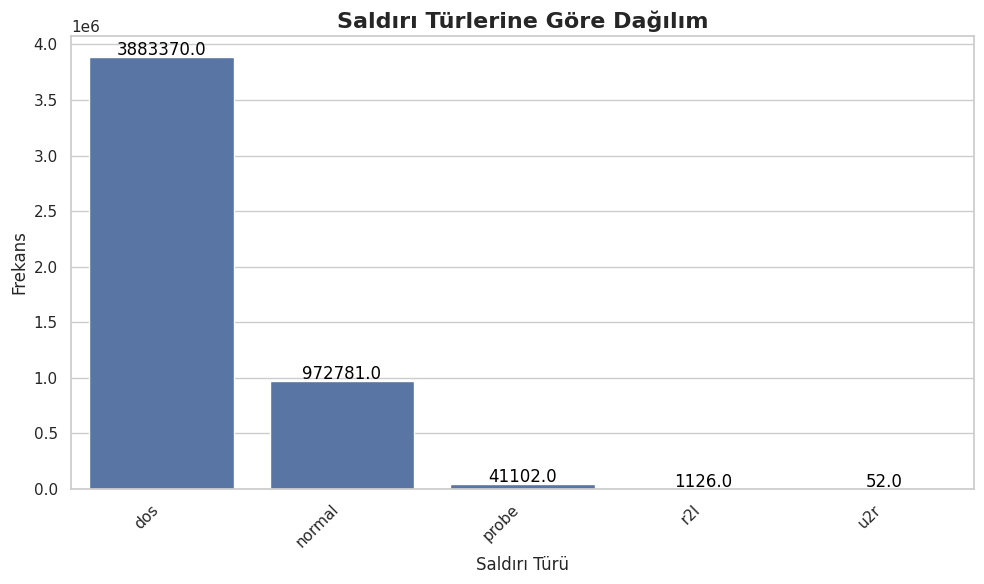

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Daha güzel ve anlaşılır bir görselleştirme için stil ve renk paletini değiştirebiliriz
plt.figure(figsize=(10,6))
sns.set(style="whitegrid")  # Beyaz grid arka plan

# Saldırı türlerine göre dağılım
ax = sns.countplot(data=data, x="multi_label", order=data['multi_label'].value_counts().index)

# Başlık, etiketler ve estetik düzenlemeler
plt.title("Saldırı Türlerine Göre Dağılım", fontsize=16, weight='bold')
plt.xlabel("Saldırı Türü", fontsize=12)
plt.ylabel("Frekans", fontsize=12)

# X eksenindeki etiketleri döndürme (yazılar kesilmesin diye)
plt.xticks(rotation=45, ha='right')

# Her çubuğun üstüne frekans değeri eklemek
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

# Grafiği gösterme
plt.tight_layout()  # Grafik sıkışmasın diye düzenleme yapar
plt.show()
